In [1]:
%%javascript
MathJax.Hub.Queue(
  ["resetEquationNumbers", MathJax.InputJax.TeX],
  ["PreProcess", MathJax.Hub],
  ["Reprocess", MathJax.Hub]
);

MathJax.Hub.Config({
    TeX: { equationNumbers: { autoNumber: "AMS" } }
});

<IPython.core.display.Javascript object>

In [2]:
from IPython.core.display import HTML
def css_styling():
    styles = open("./custom/custom.css", "r").read()
    return HTML(styles)
css_styling()

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Math

p_print = lambda p : display(Math(p))

# Métodos numéricos para la solución de EDOs: <span style="color:red">Problemas de valor inicial</span>

Consideremos el problema de valor inicial $(\mathrm{PVI})$ asociado a la EDO de primer orden:

$$
\frac{d y}{d t} = y' = f(y, t)
$$

con condición inicial:

$$
y(0) = y_0
$$

- **Nuestro objetivo al resolver este $\mathrm{PVI}$ es determinar $y(t)$ para $0 < t \leq t_f$.**
  - El objetivo de resolver esta EDO mediante cualquier método numérico es determinar $y(t)$ para tiempo $t_{n+1} = t_n + \Delta t$. Este proceso puede repetirse una vez que $y_{n+1} = y\left(t_{n+1}\right)$ fue determinado, lo cual permite calcular $t_{n+2} = t_{n+1} + \Delta t$.

## Ejemplo: PVI

<table style='background-color:white'>
<tr style='background-color:white'>
<td style="width:40%;font-size:150%">
La solución (analítica) del PVI:

$$y^\prime + y = 0,\qquad  y(0)=1$$

es:

$$y(t) = e^{-t}$$
</td>
<td style="width:60%">
<center> 
<img src=sol_numerica.png width=70%>
</center>
</td>
</tr>
</table>

## Métodos numéricos para EDOs de primer orden

## Métodos de paso simple

Consideremos el problema de valor inicial:

\begin{equation}
y^{\prime}=f(t, y), \quad y\left(t_0\right)=y_0
\end{equation}

- con $t_0$ y $y_0$ conocidos.
- Además supondremos que el problema tiene solución única para algun intervalo abierto $a<t<b$ el cual contiene a $t_0$

Consideraremos la resolución de esta EDO para puntos discretos equidistantes:

\begin{equation}
t_n=t_0+n \Delta t
\end{equation}

### Método de Euler-Cauchy

La expansión de series de Taylor para el punto correspondiente a $t_1=t_0+\Delta t$

\begin{equation}
y(t+\Delta t)=y(t)+(\Delta t) y^{\prime}(t)+\frac{(\Delta t)^2}{2} y^{\prime \prime}(t)+\ldots
\end{equation}

Si truncamos la expansión anterior a partir de su primer término

\begin{equation}
y(t+\Delta t) \approx y(t)+\Delta t\, y^{\prime}(t)
\end{equation}

y comparando con (8):

\begin{equation}
y(t+\Delta t) \approx y(t)+\Delta t\, f(t, y)
\end{equation}

Para el segundo paso, $t_2=t_1+\Delta t=t_0+2 \Delta t$ :

\begin{equation}
y_2=y_1+\Delta t\, f\left(t_1, y_1\right)
\end{equation}

En general,

\begin{equation}
y_{n+1}=y_n+\Delta t\, f\left(t_n, y_n\right)
\end{equation}

#### Ejemplo 

Resolver el PVI:

$$
y' + y = 0, \quad y(0) = 1
$$

mediante el método de Euler-Cauchy

La solución exacta es:

$$y = e^{-t}$$



A partir de 
(\ref{eq:prob_eu}):
\begin{equation}
\begin{aligned}
y^{\prime}&=f(t,y)\\
          &=-y
\end{aligned}
\end{equation}

Reemplazando en (\ref{eq:eu_gen}):

\begin{equation}
\begin{aligned}
y_{n+1}&=y_n+(\Delta t) f\left(t_n, y_n\right)\\
       &=y_n-(\Delta t) y_n\\
       &=y_n(1-\Delta t)
\end{aligned}
\end{equation}

Primero definiremos nuestra función $f(y,t)$

In [4]:
def f(t,y):
    return -y

Ahora, implementaremos el método de Euler-Cauchy:

In [11]:
def euler(t0,y0,tmax,Deltat,f):
    
    t_vec = np.arange(t0,tmax,Deltat) # crea el vector t para la solución en el intervalo
    y_vec = np.zeros_like(t_vec)      # crea un vector y, inicialmente compuesto por ceros
    y_vec[0] = y0                     # valor inicial
    
    for i in range(len(t_vec[:-1])): 
        y_vec[i+1]=y_vec[i]+Deltat*f(t_vec[i],y_vec[i]) 
    return t_vec,y_vec


h=0.5
t_eu, y_eu = euler(t0=0,
                   y0=1,
                   tmax=6,
                   Deltat=h,
                   f=f)

In [13]:
# Solución exacta
t_ex = np.linspace(0,6,1000)
y_ex = np.exp(-t_ex)

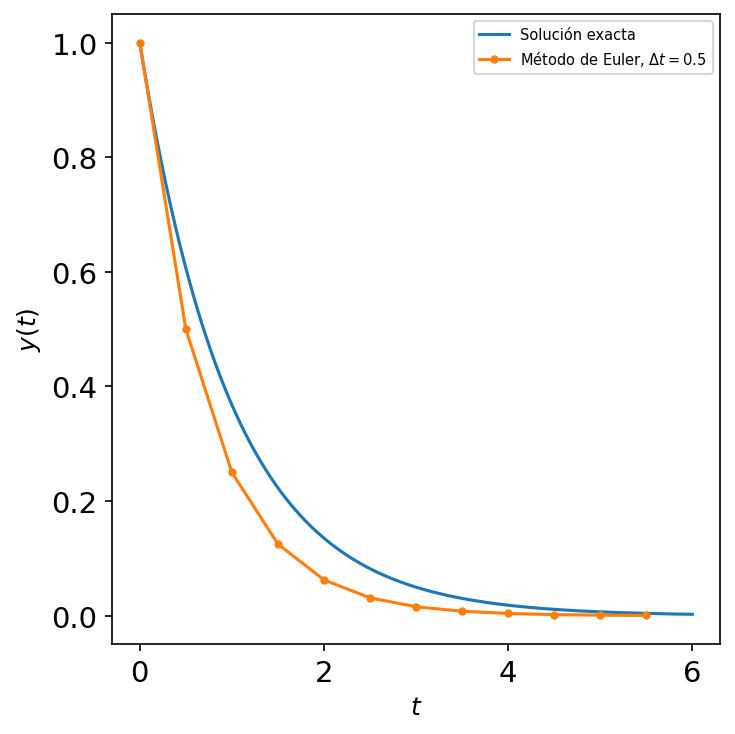

In [14]:
fig_eu1 = plt.figure(figsize=(5,5), dpi=150)
ax_eu1 = fig_eu1.add_subplot(111)


ax_eu1.plot(t_ex,y_ex,label='Solución exacta')
ax_eu1.plot(t_eu,y_eu,'.-',label=fr'Método de Euler, $\Delta t = {h}$')

ax_eu1.set_ylabel('$y(t)$',fontsize=12) 
ax_eu1.set_xlabel('$t$',fontsize=12) 

ax_eu1.legend(loc='best',fontsize=7)

ax_eu1.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()


##### Análisis del tamaño del paso de integración

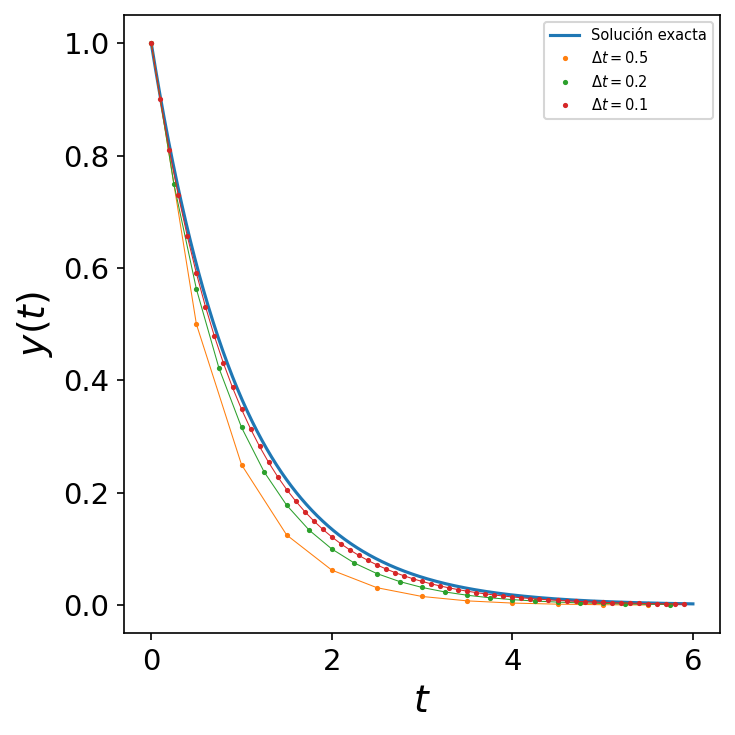

In [13]:

fig_eu2 = plt.figure(figsize=(5,5), dpi=150)
ax_eu2 = fig_eu2.add_subplot(111)

ax_eu2.plot(t_ex,y_ex,label='Solución exacta')
ax_eu2.set_ylabel('$y(t)$',fontsize=18) 
ax_eu2.set_xlabel('$t$',fontsize=18) 

h_vec = [0.5,0.25,0.1]
n = 0
for i in h_vec:
    n+=1
    x,y=euler(0,1,6,i,f)
    ax_eu2.plot(x,y,'C%d-'%(n),linewidth=0.5)
    ax_eu2.plot(x,y,'C%d.'%(n),label=fr'$\Delta t={i:2.1f}$',markersize=3)
ax_eu2.legend(loc='best',fontsize=7)

ax_eu2.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()

### Métodos de mayor orden

Si reemplazamos $y^{\prime}=f(t, y)$ y reemplazamos en la expansión de series de Taylor para $y$ :

\begin{equation}
y(t+\Delta t)=y(t)+h f+\frac{1}{2} h^2 f^{\prime}+\frac{1}{6} h^3 f^{\prime \prime}+\ldots
\end{equation}

Considerando que $f=f(t, y)=y^{\prime}$, podemos obtener términos adicionales de nuestra expansión de serie de Taylor:

\begin{equation}
\begin{aligned}
y^{\prime \prime}&=\frac{d y^{\prime}}{d t}\\
                 &=\frac{d f}{d t}\\
                 &=\frac{\partial f}{\partial t}+\frac{\partial f}{\partial y} \frac{d y}{d t}\\
                 &=f_t+f_y
\end{aligned}
\end{equation}

De forma similar:

\begin{equation}
\begin{aligned}
y^{\prime \prime \prime}&=\frac{\partial}{\partial t}\left[f_t+f f_y\right]+\frac{\partial}{\partial y}\left[f_t+f f_y\right] f\\
&=f_{t t}+2 f f_{y t}+f_t f_y+f_y^2+f^2 f_{y y}
\end{aligned}
\end{equation}

### Método de Euler mejorado

El cálculo de la expresión anterior es costoso, por lo que se adoptan otras estrategias para considerar más términos de la expansión de serie de Taylor. En particular, se escoge utilizar valores auxiliares adicionales para aumentar el orden del método

En el método de <b>Euler mejorado</b> (método de Heun), en cada paso se calcula el valor de la variable auxiliar:

\begin{equation}
y_{n+1}^*=y_n+h f\left(t_n, y_n\right)
\end{equation}
y a partir de este valor:

\begin{equation}
y_{n+1}=y_n+\frac{1}{2} h\left[f\left(t_n, y_n\right)+f\left(t_{n+1}, y_{n+1}^*\right)\right]
\end{equation}

Este método corresponde a un método predictor-corrector (se estima el valor de $y_{n+1}$ y se corrije)

#### Ejemplo

Resolver el PVI:

$$
y' + y = 0, \quad y(0)=1
$$

mediante el método de Euler mejorado.

In [15]:
def euler_mejorado(t0,y0,tmax,Deltat,f):
    
    t_vec = np.arange(t0,tmax,Deltat) # crea el vector t para la solución en el intervalo
    y_vec = np.zeros_like(t_vec)      # crea un vector y, inicialmente compuesto por ceros
    y_vec[0] = y0                     # valor inicial
    
    for i in range(len(t_vec[:-1])):
        y_prime = y_vec[i]+Deltat*f(t_vec[i],y_vec[i]) # calcula la variable auxiliar
        y_vec[i+1] = y_vec[i]+0.5*Deltat*(f(t_vec[i],y_vec[i]) +
                        f(t_vec[i],y_prime)) # corrije la variable auxiliar
        
    return t_vec,y_vec

<>:15: SyntaxWarning: invalid escape sequence '\D'
<>:17: SyntaxWarning: invalid escape sequence '\D'
<>:15: SyntaxWarning: invalid escape sequence '\D'
<>:17: SyntaxWarning: invalid escape sequence '\D'
C:\Users\yenny_sa\AppData\Local\Temp\ipykernel_9892\4269295831.py:15: SyntaxWarning: invalid escape sequence '\D'
  ax_eum.plot(x,y,'C%d*'%(n),label='$Euler; \Delta t=%2.1f$'%i)
C:\Users\yenny_sa\AppData\Local\Temp\ipykernel_9892\4269295831.py:17: SyntaxWarning: invalid escape sequence '\D'
  ax_eum.plot(xm,ym,'C%d*'%(2*n),label='$Heun; \Delta t=%2.1f$'%i)


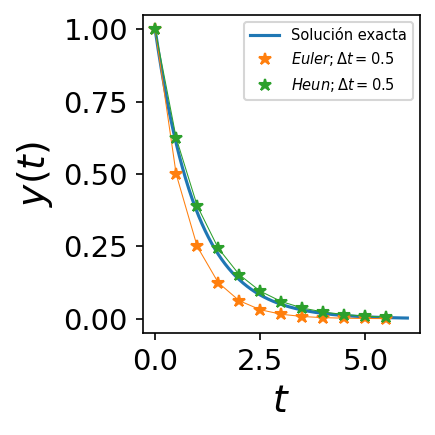

In [16]:
fig_eum = plt.figure(figsize=(3,3), dpi=150)
ax_eum = fig_eum.add_subplot(111)

ax_eum.plot(t_ex,y_ex,label='Solución exacta')
ax_eum.set_ylabel('$y(t)$',fontsize=18) ;
ax_eum.set_xlabel('$t$',fontsize=18) ;

h_vec = [0.5]
n = 0
for i in h_vec:
    n+=1
    x,y=euler(0,1,6,i,f)
    xm,ym = euler_mejorado(0,1,6,i,f)
    ax_eum.plot(x,y,'C%d-'%(n),linewidth=0.5)
    ax_eum.plot(x,y,'C%d*'%(n),label='$Euler; \Delta t=%2.1f$'%i)
    ax_eum.plot(xm,ym,'C%d-'%(2*n),linewidth=0.5)
    ax_eum.plot(xm,ym,'C%d*'%(2*n),label='$Heun; \Delta t=%2.1f$'%i)

    
ax_eum.legend(loc='best',fontsize=7)

ax_eum.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()

## Método de Runge-Kutta

El método clásico de Runge-Kutta $(\mathrm{RK})$ de cuarto orden requiere calcular sucesivamente cuatro variables auxiliares $k_1, k_2, k_3$ y $k_4$, para luego calcular el valor de $y_{n+1}$ :

\begin{equation}
\begin{aligned}
&k_1=h f\left(x_n, y_n\right) \\
&k_2=h f\left(x_n+\frac{1}{2} h, y_n+\frac{1}{2} k_1\right) \\
&k_3=h f\left(x_n+\frac{1}{2} h, y_n+\frac{1}{2} k_2\right) \\
&k_4=h f\left(x_n+h, y_n+k_3\right) \\
&y_{n+1}=y_n+\frac{1}{6}\left(k_1+2 k_2+2 k_3+k_4\right)
\end{aligned}
\end{equation}

## Método de Runge-Kutta-Fehlberg

El método de Runge-Kutta-Fehlberg (RKF) considera dos métodos de RK de distinto orden ($4^{\text {to }}$ y $5^{\text {to }}$ orden). El método de quinto orden es:

\begin{equation}
y_{n+1}=y_n+\gamma_1 k_1+\ldots+\gamma_n k_n
\end{equation}

con vector de coeficientes $\gamma=\left[\gamma_1+\ldots+\gamma_6\right]$ :

\begin{equation}
\gamma=\left[\begin{array}{llllll}
\frac{16}{135} & 0 & \frac{6656}{12825} & \frac{28561}{56430} & -\frac{9}{50} & \frac{2}{55}
\end{array}\right]
\end{equation}

El método de cuarto orden es:

\begin{equation}
y_{n+1}^*=y_n+\gamma_1^* k_1+\ldots+\gamma_n^* k_n
\end{equation}

con vector de coeficientes $\gamma=\left[\gamma_1+\ldots+\gamma_6\right]$ :

\begin{equation}
\gamma=\left[\begin{array}{lllll}
\frac{25}{218} & 0 & \frac{1408}{2585} & \frac{2197}{4104} & -\frac{1}{5}
\end{array}\right]
\end{equation}

Para ambas fórmulas, solo se requiere evaluar 6 funciones diferentes:

\begin{equation}
\begin{aligned}
&k_1=h f\left(x_n, y_n\right) \\
&k_2=h f\left(x_n+\frac{1}{4} h, y_n+\frac{1}{4} k_1\right) \\
&k_3=h f\left(x_n+\frac{3}{8} h, y_n+\frac{3}{32} k_1+\frac{9}{32} k_2\right) \\
&k_4=h f\left(x_n+\frac{12}{13} h, y_n+\frac{1932}{2197} k_1-\frac{7200}{2197} k_2+\frac{7296}{2197} k_3\right) \\
&k_5=h f\left(x_n+h, y_n+\frac{439}{218} k_1-8 k_2+\frac{3680}{513} k_3-\frac{845}{4104} k_4\right) \\
&k_6=h f\left(x_n+\frac{1}{2} h, y_n-\frac{8}{27} k_1+2 k_2-\frac{3544}{2565} k_3+\frac{1850}{4104} k_4-\frac{11}{40} k_5\right)
\end{aligned}
\end{equation}

A partir de los dos métodos, podemos estimar el error:

\begin{equation}
\epsilon_{n+1} \approx y_{n+1}-y_{n+1}^*=\frac{1}{360} k_1-\frac{128}{4276} k_3-\frac{2197}{75249} k_4+\frac{1}{5} k_{+} \frac{2}{55} k_6
\end{equation}

###  Ejemplo

Resolver el PVI:

$$
y' + y = 0, \quad y(0)=1
$$

mediante el método de Runge-Kutta-Fehlberg (RKF45)


Utilizaremos la función <span style="font-style:italic">solve_ivp</span> del módulo <span style="font-style:italic">scipy</span>

<a>https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html</a>

In [ ]:
from scipy.integrate import solve_ivp

In [ ]:
t0 = 0
tmax = 6
y0 = [1]
sol = solve_ivp(f, (t0,tmax), y0,method='RK45') 

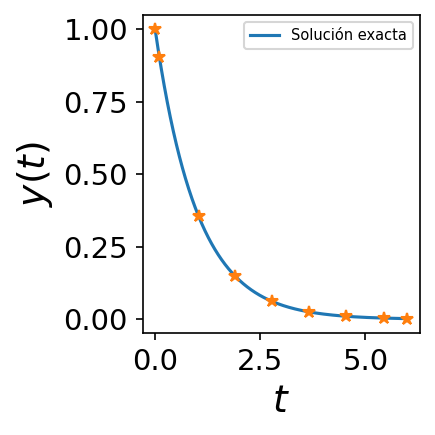

In [ ]:
fig_RKF = plt.figure(figsize=(3,3), dpi=150)
ax_RKF = fig_RKF.add_subplot(111)

ax_RKF.plot(t_ex,y_ex,label='Solución exacta')
ax_RKF.set_ylabel('$y(t)$',fontsize=18) ;
ax_RKF.set_xlabel('$t$',fontsize=18) ;
ax_RKF.plot(sol.t,sol.y[0],'*')

ax_RKF.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()

ax_RKF.legend(loc='best',fontsize=7)

## EDOs rígidas

El método de Euler hacia atrás (implicito) considera la fórmula

\begin{equation}
y_{n+1}=y_n+h f\left(x_{n+1}, y_{n+1}\right)
\end{equation}

La dificultad para evaluar $f\left(x_{n+1}, y_{n+1}\right)$ dependerá de $f$. Este método es particularmente útil para resolver EDOs rígidas (numéricamente inestables, que requieren utilizar pasos muy pequeños). Otros métodos de mayor complejidad pueden ser utilizados para obtener mejores resultados (ver método de Radau o Backward differentiation formula). Estos métodos están disponibles en la función  <span style="font-style:italic">solve_ivp</span> del módulo <span style="font-style:italic">scipy.integrate</span>

## Solución de sistemas de EDOs mediante métodos numéricos 

### Método de Euler

El método de Euler-Cauchy puede ser generalizado a un sistema de EDOs de primer orden, simplemente expresando este sistema en notación matricial:

$$\textbf{y}^{\prime} = \textbf{f}(t,\textbf{y})$$

La generalización del método de Euler-Cauchy a sistemas se obtiene reemplazando los correspondientes términos de la versión original asociada a una ecuación independiente con los términos del sistema:

$$
\mathbf{y}_{n+1}=\mathbf{y}_{n}+h \mathbf{f}\left(t_{n}, \mathbf{y}_{n}\right)
$$
con $h$ el paso de integración

La implementación de este método requiere crear una función que:
- Posea 2 variables de entradas: $t$ y $\textbf{y}$
- Posea 1 variable de salida: $\textbf{f}(t,\textbf{y})$

<i> Al momento de implementar esta función, se ha de considerar la naturaleza vectorial de $\textbf{y}$ y $\textbf{f}$ </i>

#### Ejemplo

Resolver el PVI:

$$
\begin{aligned}
y_{1}^{\prime} &=2 y_{1}-4 y_{2} \\
 y_{2}^{\prime}&=y_{1}-3 y_{2}
\end{aligned}
$$
con
$y_1(0)=3$ y $y_2(0)=0$

<br> <b>Solución exacta :

In [ ]:
import sympy 
from sympy.solvers.ode.systems import dsolve_system
from IPython.display import display, Math

y1,y2 = sympy.symbols('y1 y2',cls=sympy.Function)
t     = sympy.symbols('t')

eq1   = sympy.Eq(y1(t).diff(t),2*y1(t)-4*y2(t))
eq2   = sympy.Eq(y2(t).diff(t),y1(t)-3*y2(t))

display(eq1)
display(eq2)

eqs   = [eq1,eq2]
ics = {y1(0):3, y2(0):0}
sol = dsolve_system(eqs,ics=ics)

Eq(Derivative(y1(t), t), 2*y1(t) - 4*y2(t))

Eq(Derivative(y2(t), t), y1(t) - 3*y2(t))

In [ ]:
# solución
y1sol = sol[0][0]
y2sol = sol[0][1]
display(Math(sympy.latex(y1sol)))
display(Math(sympy.latex(y2sol)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<br>
<b> Solución mediante el método de Euler-Cauchy </b>

Función $f(t,\textbf{y})$:

$$\textbf{f}(t,\textbf{y})=\begin{bmatrix}2 & -4 \\ 1 & -3 \end{bmatrix}\begin{bmatrix} y_1 \\ y_2 \end{bmatrix}$$

$$\textbf{f}(t,\textbf{y})=\begin{bmatrix} f_1(t,y_1,y_2) \\ f_2(t,y_1,y_2) \end{bmatrix} = \begin{bmatrix}2y_1 - 4y_2 \\ y_1 -3 y_2 \end{bmatrix}$$


In [ ]:
def f(t,y):
    
    y1  = y[0]
    y2  = y[1]
    
    f_1 = 2*y1-4*y2
    f_2 = y1-3*y2
    
    return [f_1,f_2]

In [ ]:
import numpy as np

def euler(t0,y0,tmax,Deltat,f):
    
    t_vec = np.arange(t0,tmax+Deltat,Deltat)
    y_vec = np.zeros((len(t_vec),len(y0)))
    y_vec[0] = y0

    for i in range(len(t_vec[:-1])):
        y_vec[i+1]=y_vec[i]+np.multiply(Deltat,f(t_vec[i],y_vec[i]))
    return t_vec,y_vec

In [ ]:
# Valor inicial, intervalo de integración y paso de integración

y0     = [3,0]   # y_1(0) = 3   y   y_2(0) = 0
t0     = 0
tmax   = 2
Deltat = 0.1

In [ ]:
t,y = euler(t0,y0,tmax,Deltat,f)
y1,y2 = zip(np.transpose(y))

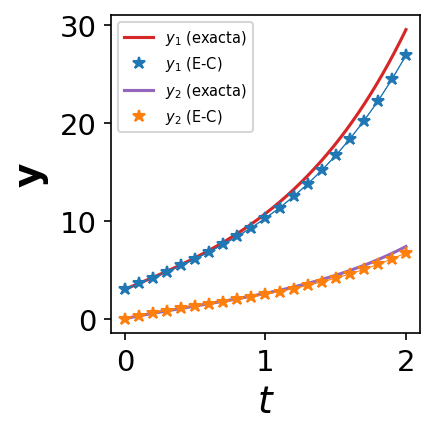

In [ ]:

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(3,3),dpi=150)
ax = fig.add_subplot(111)

y1ex = lambda t: 4*np.exp(t)-np.exp(-2*t)
y2ex = lambda t: np.exp(t)-np.exp(-2*t)

tcont = np.linspace(t0,tmax,1000)

ax.plot(tcont,y1ex(tcont),'C3-',label='$y_1$ (exacta)')
ax.plot(t,y1[0],'C0-',linewidth=0.5)
ax.plot(t,y1[0],'C0*',label='$y_1$ (E-C)')
ax.plot(tcont,y2ex(tcont),'C4-',label='$y_2$ (exacta)')
ax.plot(t,y1[0],'C0-',linewidth=0.5)
ax.plot(t,y2[0],'C1-',linewidth=0.5)
ax.plot(t,y2[0],'C1*',label='$y_2$ (E-C)')
ax.plot


ax.set_xlabel('$t$',fontsize=18)
ax.set_ylabel(r'$\mathbf{y}$',fontsize=18)

plt.legend(loc='best',fontsize=7)

ax.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()

#### Problema propuesto:

Resolver el PVI mediante el método de Euler-Cauchy:


$$
\begin{aligned}
y_{1}^{\prime} &=2t\frac{y_2^2}{y_1}\\
 y_{2}^{\prime}&=\frac{y_1}{y_2^2}
\end{aligned}
$$
con
$y_1(1)=1$, $y_2(1)=1$


<b>Cuya solución exacta es:</b>

$$
y_1(t)=t^2$$
$$y_2(t)=t$$

### Método(s) de Runge-Kutta

Los métodos de Runge-Kutta pueden ser generalizado a un sistema de EDOs de primer orden, simplemente expresando este sistema en notación matricial:

$$\textbf{y}^{\prime} = \textbf{f}(t,\textbf{y})$$

La generalización del método de Runge-Kutta a sistemas se obtiene reemplazando los correspondientes términos de la versión original asociada a una ecuación independiente con los términos del sistema. Por ejemplo, para el método de Runge-Kutta de $4^{to}$ orden:

$$
\begin{aligned}
&\mathbf{k}_{1}=h \mathbf{f}\left(x_{n}, \quad \mathbf{y}_{n}\right) \\
&\mathbf{k}_{2}=h \mathbf{f}\left(x_{n}+\frac{1}{2} h, \quad \mathbf{y}_{n}+\frac{1}{2} \mathbf{k}_{1}\right) \\
&\mathbf{k}_{3}=h \mathbf{f}\left(x_{n}+\frac{1}{2} h, \quad \mathbf{y}_{n}+\frac{1}{2} \mathbf{k}_{2}\right) \\
&\mathbf{k}_{4}=h \mathbf{f}\left(x_{n}+h, \quad \mathbf{y}_{n}+\mathbf{k}_{3}\right)
\end{aligned}
$$

$$
\mathbf{y}_{n+1}=\mathbf{y}_{n}+\frac{1}{6}\left(\mathbf{k}_{1}+2 \mathbf{k}_{2}+2 \mathbf{k}_{3}+\mathbf{k}_{4}\right)
$$
con $h$ el paso de intergación

La implementación de este método requiere crear una función que:
- Posea 2 variables de entradas: $t$ y $\textbf{y}$
- Posea 1 variable de salida: $\textbf{f}(t,\textbf{y})$

<i> Al momento de implementar esta función, se ha de considerar la naturaleza vectorial de $\textbf{y}$ y $\textbf{f}$ </i>

#### Ejemplo

Resolver el PVI:

$$
\begin{aligned}
y_{1}^{\prime} &=2 y_{1}-4 y_{2} \\
 y_{2}^{\prime}&=y_{1}-3 y_{2}
\end{aligned}
$$
con
$y_1(0)=3$ y $y_2(0)=0$

<br> <b>Solución exacta :

In [ ]:
import sympy 
from sympy.solvers.ode.systems import dsolve_system
from IPython.display import display, Math

y1,y2 = sympy.symbols('y1 y2',cls=sympy.Function)
t     = sympy.symbols('t')

eq1   = sympy.Eq(y1(t).diff(t),2*y1(t)-4*y2(t))
eq2   = sympy.Eq(y2(t).diff(t),y1(t)-3*y2(t))

display(eq1)
display(eq2)

eqs   = [eq1,eq2]
ics = {y1(0):3, y2(0):0}
sol = dsolve_system(eqs,ics=ics)

Eq(Derivative(y1(t), t), 2*y1(t) - 4*y2(t))

Eq(Derivative(y2(t), t), y1(t) - 3*y2(t))

In [ ]:
# solución
y1sol = sol[0][0]
y2sol = sol[0][1]
display(Math(sympy.latex(y1sol)))
display(Math(sympy.latex(y2sol)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<br>
<b> Solución mediante el método de Runge-Kutta-Fehlberg (RKF45) </b>

https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html

Función $f(t,\textbf{y})$:


$$\textbf{f}(t,\textbf{y})=\begin{bmatrix} f_1(t,y_1,y_2) \\ f_2(t,y_1,y_2) \end{bmatrix} = \begin{bmatrix}2y_1 - 4y_2 \\ y_1 -3 y_2 \end{bmatrix}$$


In [ ]:
def f(t,y):
    
    y1  = y[0]
    y2  = y[1]
    
    f_1 = 2*y1-4*y2
    f_2 = y1-3*y2
    
    return [f_1,f_2]

In [ ]:
# Valor inicial, intervalo de integración y paso de integración

y0     = [3,0]   # y_1(0) = 3   y   y_2(0) = 0
t0     = 0
tmax   = 2
Deltat = 0.1

In [ ]:
t,y = euler(t0,y0,tmax,Deltat,f)
y1,y2 = zip(np.transpose(y))

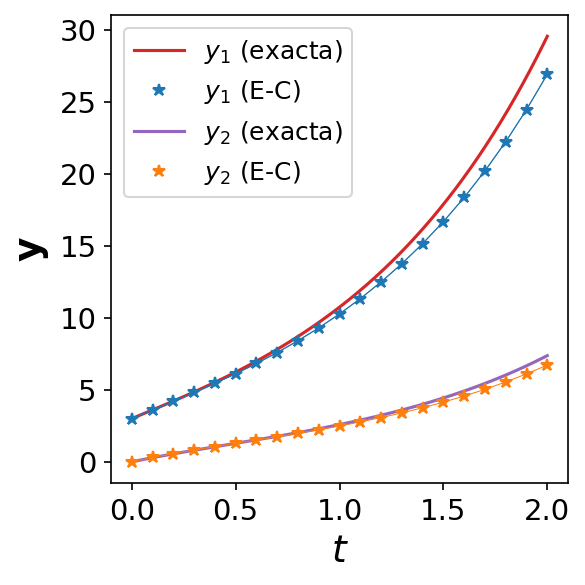

In [ ]:

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(4,4),dpi=150)
ax = fig.add_subplot(111)

y1ex = lambda t: 4*np.exp(t)-np.exp(-2*t)
y2ex = lambda t: np.exp(t)-np.exp(-2*t)

tcont = np.linspace(t0,tmax,1000)

ax.plot(tcont,y1ex(tcont),'C3-',label='$y_1$ (exacta)')
ax.plot(t,y1[0],'C0-',linewidth=0.5)
ax.plot(t,y1[0],'C0*',label='$y_1$ (E-C)')
ax.plot(tcont,y2ex(tcont),'C4-',label='$y_2$ (exacta)')
ax.plot(t,y1[0],'C0-',linewidth=0.5)
ax.plot(t,y2[0],'C1-',linewidth=0.5)
ax.plot(t,y2[0],'C1*',label='$y_2$ (E-C)')
ax.plot


ax.set_xlabel('$t$',fontsize=18)
ax.set_ylabel(r'$\mathbf{y}$',fontsize=18)

plt.legend(loc='best',fontsize=12)

ax.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()

#### Problema propuesto:

Resolver el PVI mediante el método de Runge-Kutta-Fehlberg (RKF45):


$$
\begin{aligned}
y_{1}^{\prime} &=2t\frac{y_2^2}{y_1}\\
 y_{2}^{\prime}&=\frac{y_1}{y_2^2}
\end{aligned}
$$
con
$y_1(1)=1$ y $y_2(1)=1$


In [24]:
from scipy.integrate import solve_ivp
import numpy as np

def f(t, y):
    y1, y2 = y
    dy1dt = 2*t * (y2**2) / y1
    dy2dt = y1 / (y2**2)
    return [dy1dt, dy2dt]

t_span = (1.0, 2.0)
y0 = [1.0, 1.0]
t_eval = np.linspace(1.0, 2.0, 10)

sol = solve_ivp(f, t_span, y0, method='RK45', t_eval=t_eval)

t_RKF = sol.t
y1_RKF = sol.y[0, :]
y2_RKF = sol.y[1, :]

In [25]:
y1_exact = t_RKF**2
y2_exact = t_RKF

<>:16: SyntaxWarning: invalid escape sequence '\,'
<>:16: SyntaxWarning: invalid escape sequence '\,'
C:\Users\yenny_sa\AppData\Local\Temp\ipykernel_9892\918519274.py:16: SyntaxWarning: invalid escape sequence '\,'
  ax.set_ylabel('$y_1(t),\, y_2(t)$', fontsize=14)


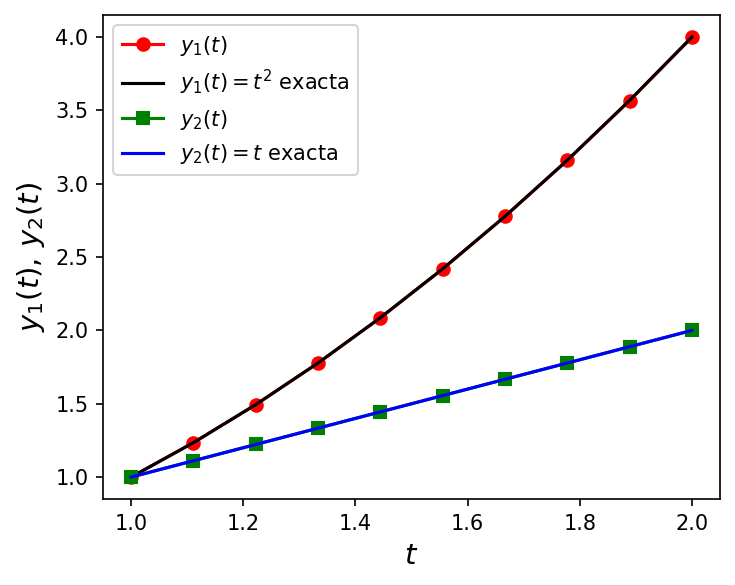

In [35]:
import matplotlib.pyplot as plt


# Importar Matplotlib y crear la figura
fig = plt.figure(figsize=(5, 4), dpi=150)
ax = fig.add_subplot(111)

# Graficar y_1(t) y y_2(t)
ax.plot(t_RKF, y1_RKF, 'ro-', label='$y_1(t)$')
ax.plot(t_RKF, y1_exact, 'k-',  label='$y_1(t)=t^2$ exacta')
ax.plot(t_RKF, y2_RKF, 'gs-', label='$y_2(t)$')
ax.plot(t_RKF, y2_exact, 'b-',  label='$y_2(t)=t$ exacta')

# Etiquetas, leyenda y estilo
ax.set_xlabel('$t$', fontsize=14)
ax.set_ylabel('$y_1(t),\, y_2(t)$', fontsize=14)

ax.legend(loc='best', fontsize=10)

ax.tick_params(axis='both', which='major', labelsize=10)
plt.tight_layout()
plt.show()

<b>Solución exacta</b>

$$
y_1(t)=t^2$$
$$y_2(t)=t$$

# Solución de EDOs de orden $n>1$ mediante métodos numéricos 

El problema de valor inicial para edos de orden $n$ consiste en la EDO:

$$
y^{(m)}=f\left(x, y, y^{\prime}, y^{\prime \prime}, \cdots, y^{(m-1)}\right)
$$

y condiciones iniciales:

$$
y\left(t_{0}\right)=K_{1},\quad y^{\prime}\left(t_{0}\right)=K_{2},\quad \cdots,\quad y^{(m-1)}\left(t_{0}\right)=K_{n}
$$

con $K_1$, $K_2$, ..., $K_n$ constantes

<br>

Es posible transformar una edo de orden $n>1$ a un sistema de EDOs de primer orden al definir:

$$
y_{1}=y, \quad y_{2}=y^{\prime}, \quad y_{3}=y^{\prime \prime}, \quad \cdots, \quad y_{m}=y^{(m-1)}
$$

En base a estas definiciones obtendremos el sistema de $n$ EDOs de primer orden:

$$
\begin{aligned}
y_{1}^{\prime}&=y_{2} \\
y_{2}^{\prime}&=y_{3} \\
& \vdots  \\
y_{n-1}^{\prime}&=y_{n} \\
y_{n}^{\prime}&=f\left(x, y_{1}, \cdots, y_{n}\right)
\end{aligned}
$$

con condiciones iniciales:

$$y(t_0)=y_1(t_0)=K_1,\quad y^\prime(t_0)=y_2(t_0)=K_2,\quad\cdots,\quad, y^{(n-1)}(t_0)=y_{n}(t_0)=K_n$$

Una vez transformada en sistema, la EDO deberá ser resuelta mediante metodologías empleadas para resolver sistemas de EDOs de primer orden


<br>
<h1>Ejemplo</h1>

Resolver el PVI:


$$
y^{\prime \prime}-t y^{\prime}+4 y=0
$$

con: $y(0)=3$, $y^\prime(0)=0$


<br>
<b> Cuya solución exacta es: </b>

$$
y=t^{4}-6 t^{2}+3
$$

<br>

Iniciamos escribiendo la EDO en su forma estandar:
<br>

$$
y^{\prime \prime}= t y^{\prime}-4 y = f(t,y,y^\prime)
$$



Ahora, transformaremos la EDO a un sistema de EDOs lineales. Para esto, definiremos:

$$y_1=y \qquad y_2=y^{\prime}$$

y las condiciones iniciales:

$$y(0)=y_1(0)=3\qquad y^\prime(0)=y_2(0)=0$$



A partir de estas definiciones, el sistema a resolver será:

$$\begin{aligned}
y_1^\prime &= y_2 \\
y_2^\prime &= f(t,y_1,y_2)
\end{aligned}$$


Para facilitar la compresión de los procedimientos realizados a continuación, definiremos:
$$
\begin{aligned}
f_1(t,y_1,y_2) &= y_2\\
f_2(t,y_1,y_2) &= f(t,y_1,y_2)
\end{aligned}$$

Al expresar esta ecuación en forma vectorial:

$$\textbf{y}^\prime = \textbf{f}(t,y_1,y_2)=\begin{bmatrix} f_1(t,y_1,y_2) \\ f_2(t,y_1,y_2) \end{bmatrix}$$

En este ejemplo:

$$f_2(t,y_1,y_2) = -4y_1+ty_2$$

In [27]:
def f(t,y):
    
    y1 = y[0]
    y2 = y[1]
    
    f_1 = y2
    f_2 = -4*y1+t*y2
    
    return [f_1,f_2]

In [28]:
# Valor inicial, intervalo de integración y paso de integración

y0     = [3,0]   # y_1(0) = 3   y   y_2(0) = 0
t0     = 0
tmax   = 2
# tmax   = 10 # inestable
Deltat = 0.1

In [29]:
from scipy.integrate import solve_ivp
import numpy as np

teval=np.arange(t0,tmax+Deltat,Deltat)

sol = solve_ivp(f, (t0,tmax), y0,t_eval=teval)  #, method='RK45',t_eval=teval) 

y1 = sol.y[0]
y2 = sol.y[1]
t  = sol.t

print(sol)

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.000e-01 ...  1.900e+00  2.000e+00]
        y: [[ 3.000e+00  2.940e+00 ... -5.632e+00 -5.005e+00]
            [ 0.000e+00 -1.196e+00 ...  4.634e+00  8.000e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 56
     njev: 0
      nlu: 0


Para obtener la solución $y(t)$, simplemente deberemos volver sobre nuestra definición:

$$y_1(t)=y(t)$$



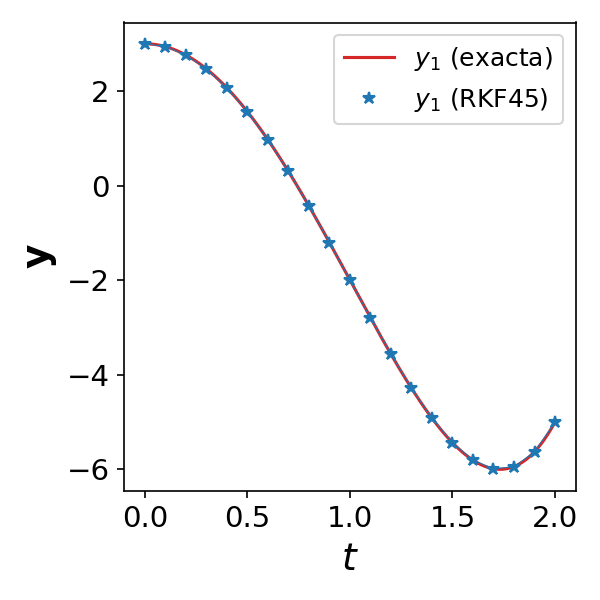

In [30]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(4,4),dpi=150)
ax = fig.add_subplot(111)

y1ex = lambda t: t**4-6 *t**2+3


tcont = np.linspace(t0,tmax,1000)

ax.plot(tcont,y1ex(tcont),'C3-',label='$y_1$ (exacta)')
ax.plot(t,y1,'C0-',linewidth=0.5)
ax.plot(t,y1,'C0*',label='$y_1$ (RKF45)')


ax.set_xlabel('$t$',fontsize=18)
ax.set_ylabel(r'$\mathbf{y}$',fontsize=18)

plt.legend(loc='best',fontsize=12)

ax.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()

<br>

<h1> Problema propuesto:</h1>

Resolver el PVI mediante el método de Runge-Kutta-Fehlberg (RKF45):

$$
y^{\prime \prime}+5 y^{\prime}+4 y=10 e^{-3 t}
$$

con $y(0)=0$, $y^\prime(0)=1$

<b>Cuya solución exacta es: </b>

$$y(t)=2e^{-t}+3e^{-4t}-5e^{-3t}$$

<br>

Forma estándar:
$$
y^{\prime \prime}=-5 y^{\prime}-4 y+10 e^{-3 t} = f(t,y,y^\prime)
$$

Se define:

$$y = y^\prime, \qquad y_2 = y^\prime$$

El sistema asociado es:

$$
\begin{aligned}
y_1^\prime &= y_2\\ 
y_2^\prime &= -5y_2-4y_1+10e^{-3t}= f_1(t,y_1,y_2) 
\end{aligned}
$$

con:

$$\textbf{f}(t,y_1,y_2)=\begin{bmatrix} f_1\\ f_2 \end{bmatrix} = \begin{bmatrix} y_2 \\ -5y_2-4y_1+10e^{-3t}\end{bmatrix}$$